In [1]:
import numpy as np
from sklearn.metrics import pairwise_distances

def calculate_pertinences(
    x : np.ndarray,
    c : np.ndarray,
):
    dist = pairwise_distances(x, c, metric="euclidean")
    pert = 1/dist
    pert /= pert.sum(axis=1, keepdims=True)
    return pert
    

In [ ]:
from sklearn.datasets import make_blobs

centers = np.array(
    [
        [1, 1],
        [1, -1],
        [-1, -1],
        [-1, 1],
        [0,0],
    ]
)

X, y = make_blobs(
    n_samples=1000,
    centers=centers,
    n_features=5,
    cluster_std=0.7,
    random_state=42,
)

print(X.shape, y.shape)

(100, 2) (100,)


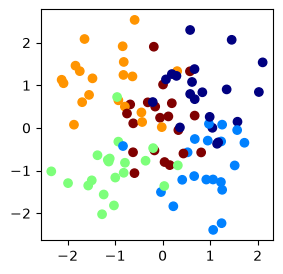

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.scatter(X[:,0], X[:,1], c=y, cmap='jet')
plt.show()

In [4]:
y

array([4, 1, 2, 1, 4, 0, 2, 3, 0, 0, 0, 4, 2, 4, 4, 4, 1, 3, 4, 2, 2, 3,
       4, 3, 4, 0, 2, 0, 4, 1, 3, 1, 1, 4, 1, 1, 4, 0, 3, 4, 3, 1, 1, 1,
       3, 4, 2, 0, 4, 0, 3, 2, 3, 4, 1, 4, 2, 3, 0, 4, 2, 2, 3, 3, 3, 1,
       3, 3, 2, 4, 2, 3, 1, 3, 0, 3, 0, 0, 0, 3, 0, 2, 1, 2, 0, 2, 0, 1,
       1, 2, 1, 2, 1, 2, 2, 0, 1, 0, 4, 0])

In [5]:
pert = calculate_pertinences(X, centers)
pert

array([[0.13724911, 0.14726608, 0.1045756 , 0.10080112, 0.51010809],
       [0.1120492 , 0.41038651, 0.17979004, 0.09775396, 0.20002029],
       [0.12173399, 0.14220084, 0.35391641, 0.19607677, 0.186072  ],
       [0.09321376, 0.55873728, 0.12037806, 0.07435071, 0.15332019],
       [0.1248196 , 0.09498283, 0.13727718, 0.39509495, 0.24782543],
       [0.31247857, 0.25117044, 0.11422486, 0.11864953, 0.2034766 ],
       [0.04875824, 0.0734596 , 0.71259818, 0.06491711, 0.10026688],
       [0.10954135, 0.08268092, 0.12274964, 0.54036243, 0.14466566],
       [0.38445253, 0.1892817 , 0.11265625, 0.13170719, 0.18190233],
       [0.15157466, 0.14913577, 0.1048937 , 0.10573185, 0.48866401],
       [0.65071087, 0.08182112, 0.05808652, 0.08182167, 0.12755982],
       [0.23918053, 0.12270687, 0.1099082 , 0.17188164, 0.35632276],
       [0.08550578, 0.11425672, 0.52711264, 0.1252218 , 0.14790307],
       [0.11949747, 0.11261407, 0.18855876, 0.22760626, 0.35172345],
       [0.1096397 , 0.16707672, 0.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, p_train, p_test = train_test_split(
    X,
    y,
    pert,
    test_size=0.2,
    random_state=42,
)

In [7]:
import torch 

x_tensor = torch.tensor(X_train).float()
y_tensor = torch.tensor(y_train)
p_tensor = torch.tensor(p_train).float()

print(x_tensor.shape, y_tensor.shape, p_tensor.shape)

torch.Size([80, 2]) torch.Size([80]) torch.Size([80, 5])


In [8]:
from mlxp import models
from mlxp import training

clf = models.MLP(
    input_dim = 2,
    hidden_dim = 100,
    output_dim = 5,
    n_layers = 20,
    dropout = 0.0,
    block_type = "simple" # "simple" or "residual"
)

print(clf)

MLP(
  (input_layer): Linear(in_features=2, out_features=100, bias=True)
  (input_batch_norm): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (hidden_layers): ModuleList(
    (0-19): 20 x SimpleBlock(
      (linear): Linear(in_features=100, out_features=100, bias=True)
      (batch_norm): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU()
      (dropout): Identity()
    )
  )
  (output_layer): Linear(in_features=100, out_features=5, bias=True)
)


In [ ]:
import torch.nn as nn

train_data = training.train_mlp(
    model=clf,
    x=x_tensor,
    y=y_tensor,
    p=y_tensor,
    optimizer_type="adam",
    device='cuda:0',
    #batch_size=100,
    val_split=0.2,
    epochs=100,
    seed=42,
    weight_decay=5e-4,
    loss_fn=nn.CrossEntropyLoss(),
    patience=1000000,
    verbose=True,
    lr=1e-3,
    task="classification",
    record_nc=True,
)

epoch 1/100 - train_loss: 1.7464 - val_loss: 1.6253 - train_acc: 0.1719 - val_acc: 0.1250
epoch 2/100 - train_loss: 1.6557 - val_loss: 1.6230 - train_acc: 0.2031 - val_acc: 0.1875
epoch 3/100 - train_loss: 1.6303 - val_loss: 1.6220 - train_acc: 0.2188 - val_acc: 0.1875
epoch 4/100 - train_loss: 1.7169 - val_loss: 1.6210 - train_acc: 0.1875 - val_acc: 0.1875
epoch 5/100 - train_loss: 1.5178 - val_loss: 1.6190 - train_acc: 0.2500 - val_acc: 0.1875
epoch 6/100 - train_loss: 1.5156 - val_loss: 1.6164 - train_acc: 0.3281 - val_acc: 0.1875
epoch 7/100 - train_loss: 1.4317 - val_loss: 1.6136 - train_acc: 0.4219 - val_acc: 0.1875
epoch 8/100 - train_loss: 1.4557 - val_loss: 1.6109 - train_acc: 0.3125 - val_acc: 0.1875
epoch 9/100 - train_loss: 1.3300 - val_loss: 1.6116 - train_acc: 0.5000 - val_acc: 0.1875
epoch 10/100 - train_loss: 1.3610 - val_loss: 1.6163 - train_acc: 0.5312 - val_acc: 0.0625
epoch 11/100 - train_loss: 1.2172 - val_loss: 1.6198 - train_acc: 0.5312 - val_acc: 0.1250
epoch 12

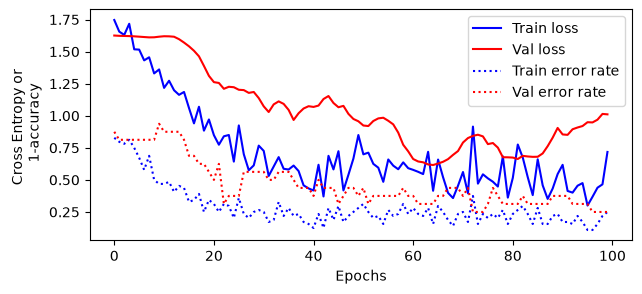

In [10]:
import matplotlib.pyplot as plt 
import numpy as np 

plt.figure(figsize=(7,3))
plt.plot(train_data['train_loss'], 'b', label='Train loss')
plt.plot(train_data['val_loss'], 'r', label='Val loss')
plt.plot(1-np.array(train_data['train_acc']), 'b:', label='Train error rate')
plt.plot(1-np.array(train_data['val_acc']), 'r:', label='Val error rate')
#plt.plot(train_data['train_nc1'], 'b--', label='Train NC1')
#plt.plot(train_data['val_nc1'], 'r--', label='Val NC1')
plt.ylabel('Cross Entropy or \n 1-accuracy')
plt.xlabel('Epochs')
plt.legend()
#plt.semilogy()
plt.show()

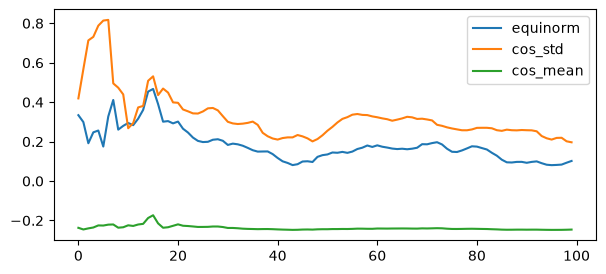

In [11]:
plt.figure(figsize=(7,3))

equinorm = [a['equinorm'] for a in train_data['train_nc2']]
cos_std = [a['cos_std'] for a in train_data['train_nc2']]
cos_mean = [a['cos_mean'] for a in train_data['train_nc2']]
plt.plot(equinorm, label='equinorm')
plt.plot(cos_std, label='cos_std')
plt.plot(cos_mean, label='cos_mean')
plt.legend()

plt.show()

In [12]:
from mlxp.models import get_embeddings

z = get_embeddings(model=clf, x=x_tensor)

In [13]:
from sklearn.decomposition import PCA

z_pca = PCA(n_components=2).fit_transform(
    z.detach().cpu().numpy()
)

#z_pca

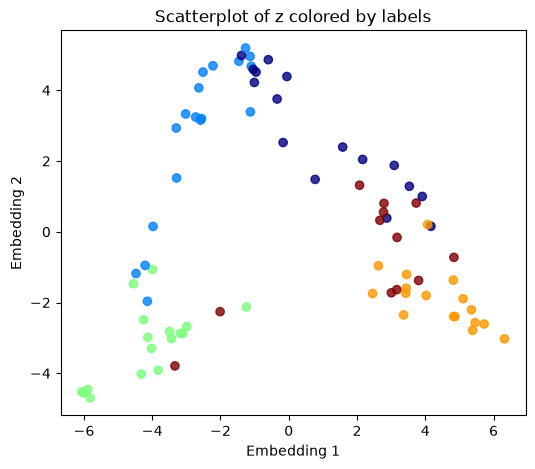

In [15]:


plt.figure(figsize=(6, 5))


plt.scatter(
    z_pca[:, 0],
    z_pca[:, 1],
    c=y_tensor.detach().cpu().numpy(),
    cmap="viridis",
    alpha=0.8,
)

plt.gca().collections[0].set_cmap(plt.colormaps["jet"].resampled(5))
plt.xlabel("Embedding 1")
plt.ylabel("Embedding 2")
plt.title("Scatterplot of z colored by labels")
#plt.legend(label="Label")
plt.show()